In [110]:
# Import the necessary libraries for the programme
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score,classification_report
from sklearn.tree import DecisionTreeRegressor

In [74]:
df = pd.read_csv('test_energy_data.csv')

In [75]:
df.head(3)

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,24563,15,4,28.52,Weekday,2865.57
1,Commercial,27583,56,23,23.07,Weekend,4283.80
2,Commercial,45313,4,44,33.56,Weekday,5067.83


In [76]:
df.columns

Index(['Building Type', 'Square Footage', 'Number of Occupants',
       'Appliances Used', 'Average Temperature', 'Day of Week',
       'Energy Consumption'],
      dtype='object')

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        100 non-null    object 
 1   Square Footage       100 non-null    int64  
 2   Number of Occupants  100 non-null    int64  
 3   Appliances Used      100 non-null    int64  
 4   Average Temperature  100 non-null    float64
 5   Day of Week          100 non-null    object 
 6   Energy Consumption   100 non-null    float64
dtypes: float64(2), int64(3), object(2)
memory usage: 5.6+ KB


In [78]:
df.describe()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,100.000000,100.000000,100.000000,100.000000,100.00000
mean,25881.920000,47.230000,26.970000,22.043300,4187.57830
std,13711.075264,29.905526,14.237846,6.957951,832.55985
min,1161.000000,2.000000,1.000000,10.400000,2351.97000
25%,14161.000000,21.000000,16.750000,15.682500,3621.92500
50%,27582.500000,47.000000,27.500000,21.970000,4249.39000
75%,38109.500000,73.000000,39.250000,27.492500,4797.17500
max,49354.000000,99.000000,49.000000,34.710000,6042.56000


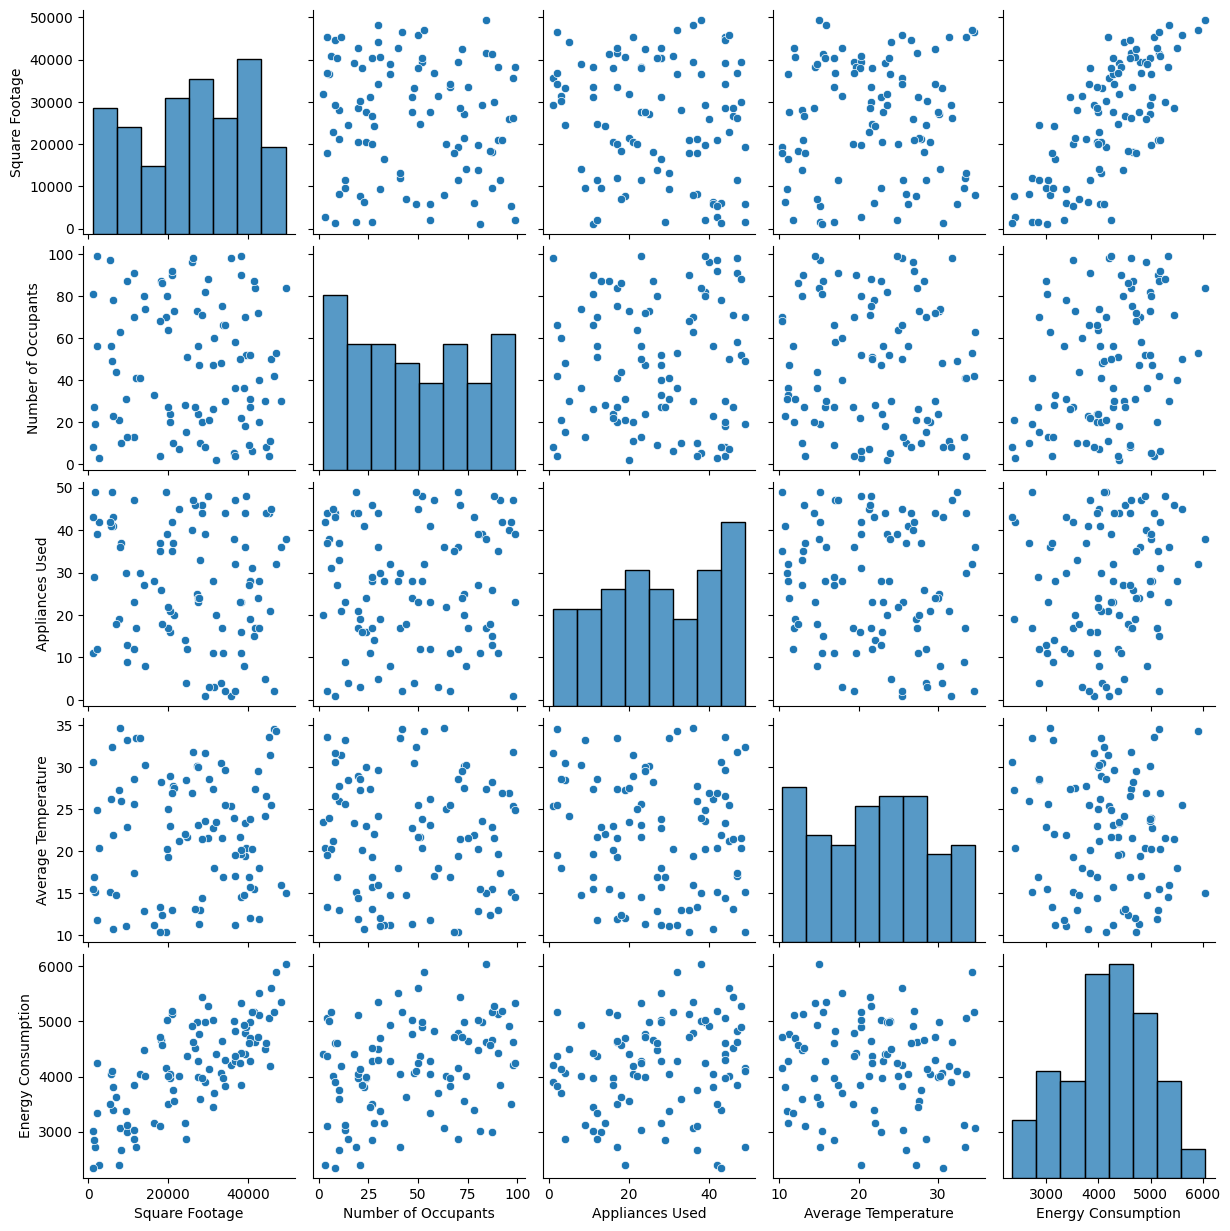

In [79]:
sns.pairplot(
                data = df
)

In [80]:
df['Day of Week'].unique()

array(['Weekday', 'Weekend'], dtype=object)

In [81]:
df['Day of Week'] = df['Day of Week'].map({
                            'Weekday' :  1,
                            'Weekend' : 0
})

In [82]:
df['Building Type'].unique()

array(['Residential', 'Commercial', 'Industrial'], dtype=object)

In [ ]:
onc = OneHotEncoder(sparse_output=False)

In [84]:
new_building_dataset = onc.fit_transform(df[['Building Type']])

In [85]:
new_building_dataset[:10]

array([[0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.]])

In [86]:
df = df.drop(columns=['Building Type'])
df = pd.concat([df,pd.DataFrame(new_building_dataset,columns=onc.get_feature_names_out())],axis=1)

In [87]:
df

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption,Building Type_Commercial,Building Type_Industrial,Building Type_Residential
0,24563,15,4,28.52,1,2865.57,0.0,0.0,1.0
1,27583,56,23,23.07,0,4283.80,1.0,0.0,0.0
2,45313,4,44,33.56,1,5067.83,1.0,0.0,0.0
3,41625,84,17,27.39,0,4624.30,0.0,0.0,1.0
4,36720,58,47,17.08,1,4820.59,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
95,1161,81,11,15.45,0,3010.81,1.0,0.0,0.0
96,37943,50,23,21.73,0,4248.49,0.0,0.0,1.0
97,1558,27,29,16.86,0,2843.60,1.0,0.0,0.0
98,2145,56,12,11.77,0,3348.39,0.0,1.0,0.0


In [89]:
X , y = df.drop(columns = ['Energy Consumption']) , df['Energy Consumption']

In [90]:
X

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Building Type_Commercial,Building Type_Industrial,Building Type_Residential
0,24563,15,4,28.52,1,0.0,0.0,1.0
1,27583,56,23,23.07,0,1.0,0.0,0.0
2,45313,4,44,33.56,1,1.0,0.0,0.0
3,41625,84,17,27.39,0,0.0,0.0,1.0
4,36720,58,47,17.08,1,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...
95,1161,81,11,15.45,0,1.0,0.0,0.0
96,37943,50,23,21.73,0,0.0,0.0,1.0
97,1558,27,29,16.86,0,1.0,0.0,0.0
98,2145,56,12,11.77,0,0.0,1.0,0.0


In [91]:
y

0     2865.57
1     4283.80
2     5067.83
3     4624.30
4     4820.59
       ...   
95    3010.81
96    4248.49
97    2843.60
98    3348.39
99    4722.59
Name: Energy Consumption, Length: 100, dtype: float64

In [93]:
X_train , X_test , y_train , y_test = train_test_split(
                                                            X,
                                                            y,
                                                            test_size = 0.3 ,
                                                            random_state = 42
)

In [99]:
scale = StandardScaler()

In [100]:
X_train_scalled = scale.fit_transform(X_train)
X_test_scalled = scale.transform(X_test)

In [94]:
from sklearn.ensemble import AdaBoostRegressor

In [97]:
adbr = AdaBoostRegressor(
                            estimator = DecisionTreeRegressor(
                                                                    criterion = 'squared_error',
                                                                    max_depth = 5

                            ),
                            n_estimators = 25,
                            # learning_rate = 0.1,
                            loss = 'linear',
)

In [101]:
adbr.fit(X_train_scalled,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeR...r(max_depth=5)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",25
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provi

In [104]:
adbr.get_params()

{'estimator__ccp_alpha': 0.0,
 'estimator__criterion': 'squared_error',
 'estimator__max_depth': 5,
 'estimator__max_features': None,
 'estimator__max_leaf_nodes': None,
 'estimator__min_impurity_decrease': 0.0,
 'estimator__min_samples_leaf': 1,
 'estimator__min_samples_split': 2,
 'estimator__min_weight_fraction_leaf': 0.0,
 'estimator__monotonic_cst': None,
 'estimator__random_state': None,
 'estimator__splitter': 'best',
 'estimator': DecisionTreeRegressor(max_depth=5),
 'learning_rate': 1.0,
 'loss': 'linear',
 'n_estimators': 25,
 'random_state': None}

In [105]:
y_pred_adbr = adbr.predict(X_test_scalled)

In [106]:
r2_score(y_test,y_pred_adbr)

0.7523931978772619

In [108]:
root_mean_squared_error(y_test,y_pred_adbr)

402.0282688007761

In [109]:
mean_absolute_error(y_test,y_pred_adbr)

336.1636646825397

In [116]:
cross_val_score(
                    adbr , 
                    X , 
                    y,
                    cv = 7,
                    scoring='r2'
).mean()

np.float64(0.8199281993402655)